# VAE（变分自编码器）实现 - CIFAR-10数据集

## VAE 的原理

变分自编码器（Variational Autoencoder, VAE）是一种生成模型，由Kingma和Welling在2013年提出。VAE结合了深度学习和变分推断的思想，能够学习数据的潜在表示并生成新样本。

### VAE的基本思想

VAE的核心思想是将输入数据映射到潜在空间的概率分布，而不是像传统自编码器那样映射到确定性的潜在向量。这种概率性表示使VAE能够：
- 生成多样化的新样本
- 在潜在空间中进行平滑插值
- 学习数据的有意义表示

### VAE的数学表达

#### 模型定义

假设我们有观测数据 $x$，我们希望学习一个潜在变量 $z$，使得 $p(x|z)$ 能够表示我们的数据生成过程。理想情况下，我们想要计算后验分布 $p(z|x)$，但这通常是难以直接计算的。

VAE使用变分推断来近似这个后验分布，引入一个编码器网络 $q_{\phi}(z|x)$ 作为 $p(z|x)$ 的近似，同时使用解码器网络 $p_{\theta}(x|z)$ 重建原始数据。

#### VAE的目标函数：证据下界（ELBO）

VAE的训练目标是最大化证据下界（Evidence Lower Bound, ELBO）：

$$\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{z \sim q_{\phi}(z|x)} \left[ \log p_{\theta}(x|z) \right] - D_{KL} \left( q_{\phi}(z|x) \| p(z) \right)$$

这个目标函数可以分解为两部分：

1. **重建项** $\mathbb{E}_{z \sim q_{\phi}(z|x)} \left[ \log p_{\theta}(x|z) \right]$：
   - 衡量从潜在变量重建原始数据的质量
   - 通常使用均方误差（MSE）或二元交叉熵（BCE）实现

2. **KL散度项** $D_{KL} \left( q_{\phi}(z|x) \| p(z) \right)$：
   - 衡量近似后验分布 $q_{\phi}(z|x)$ 与先验分布 $p(z)$ 之间的差异
   - 作为正则化项，防止编码器产生过于复杂的分布

#### 高斯假设

在标准VAE中，假设：
- 先验分布：$p(z) = \mathcal{N}(0, I)$（标准正态分布）
- 近似后验分布：$q_{\phi}(z|x) = \mathcal{N}(\mu_{\phi}(x), \text{diag}(\sigma^2_{\phi}(x)))$（对角高斯分布）
- 条件似然：$p_{\theta}(x|z)$（通常是高斯分布或伯努利分布，取决于数据类型）

#### KL散度的封闭解

在高斯假设下，KL散度项有解析解：

$$D_{KL} \left( q_{\phi}(z|x) \| p(z) \right) = \frac{1}{2} \sum_{j=1}^{J} \left( 1 + \log(\sigma^2_j) - \mu^2_j - \sigma^2_j \right)$$

其中 $J$ 是潜在空间的维度，$\mu_j$ 和 $\sigma^2_j$ 分别是 $q_{\phi}(z|x)$ 的均值和方差的第 $j$ 个元素。

### 重参数化技巧

为了使整个网络可以通过反向传播进行端到端训练，VAE采用了重参数化技巧。具体来说，我们不直接从 $q_{\phi}(z|x)$ 中采样，而是使用：

$$z = \mu_{\phi}(x) + \sigma_{\phi}(x) \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

其中 $\odot$ 表示元素级乘法。这样，梯度可以通过采样操作向后传播。

### VAE的优缺点

#### 优点
- 有坚实的概率理论基础
- 同时是生成模型和表示学习模型
- 训练相对稳定
- 潜在空间有良好的结构和平滑特性

#### 缺点
- 生成的样本可能比GAN模糊
- KL散度项可能导致潜在空间中的过度正则化
- 高维复杂数据上的表现可能不如其他生成模型
- 假设潜在变量的独立性可能限制表达能力
```

本实现中使用卷积神经网络构建VAE的编码器和解码器，应用于CIFAR-10彩色图像数据集。

## 环境设置

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model/vae"
RESULT_SAVE_PATH = "../result/vae"

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


## 超参数设置

VAE模型的性能和行为很大程度上取决于其超参数设置：

- `batch_size`: 每批训练样本的数量，影响优化过程的稳定性
- `image_size`: 图像尺寸，CIFAR-10为32x32
- `nc`: 输入图像的通道数，彩色图像为3通道(RGB)
- `latent_dim`: 潜在空间的维度，决定了模型的压缩程度和生成能力
- `hidden_dim`: 编码器和解码器中隐藏层的维度
- `num_epochs`: 训练的总轮数
- `learning_rate`: 优化器的学习率，影响训练速度和稳定性

与GAN不同，VAE通常训练更加稳定，因此可以使用相对较大的学习率。潜在空间维度的选择需要权衡信息压缩程度和重建质量。

In [ ]:
batch_size = 256
image_size = 32
nc = 3  # 训练图像的通道数 (RGB)
latent_dim = 128  # 潜在向量z的大小
hidden_dim = 256
num_epochs = 100
learning_rate = 1e-3

In [ ]:
# 定义数据转换：转换为张量
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为[0,1]范围的张量
])

# 加载CIFAR-10训练数据集
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## VAE模型结构

VAE由两个主要组件组成：编码器和解码器。编码器将输入数据映射到潜在分布的参数（均值和方差），而解码器将从该分布中采样的潜在向量映射回原始数据空间。

### 编码器

编码器网络采用卷积神经网络结构，通过降采样逐步提取输入数据的高阶特征：
- 使用多层卷积层和批归一化降低图像尺寸并增加深度
- 使用LeakyReLU激活函数增强网络的表达能力
- 编码器输出潜在分布的均值(μ)和对数方差(log σ²)，而不是单个潜在向量

### 解码器

解码器网络负责将潜在向量重建为原始图像：
- 使用转置卷积（反卷积）进行上采样
- 通过批归一化和ReLU激活函数实现非线性变换
- 最终层使用Sigmoid激活函数确保输出在[0,1]范围内

### 残差连接

本实现还添加了残差连接，这有助于：
- 改善梯度流动
- 减轻梯度消失问题
- 实现更深层网络的有效训练

In [ ]:
class VAE(nn.Module):
    """用于图像生成和重建的变分自编码器（VAE）模型。
    
    本VAE实现采用深度卷积结构和残差连接，将图像编码到潜在空间，再解码还原。
    
    Attributes:
        encoder: 包含编码用卷积层的Sequential模块
        flatten_size: 展平特征图后的大小
        enc_fc1, enc_fc2: 编码特征的全连接层
        fc_mu, fc_log_var: 生成潜在分布参数的全连接层
        dec_fc1, dec_fc2, dec_fc3: 解码潜在向量的全连接层
        decoder: 包含解码用反卷积层的Sequential模块
        enc_res1, dec_res1: 用于更好梯度流的残差连接模块
    """
    def __init__(self):
        """初始化VAE模型结构。"""
        super(VAE, self).__init__()
        
        # 更深的编码器
        self.encoder = nn.Sequential(
            # 3x32x32 -> 32x16x16
            nn.Conv2d(nc, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 32x16x16 -> 64x8x8
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 64x8x8 -> 128x4x4
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 128x4x4 -> 256x2x2
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # 展平和全连接层
        self.flatten_size = 256 * 2 * 2
        self.enc_fc1 = nn.Linear(self.flatten_size, hidden_dim * 2)
        self.enc_fc2 = nn.Linear(hidden_dim * 2, hidden_dim)
        
        # 潜在分布的均值和对数方差
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)
        
        # 解码器初始全连接层
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.dec_fc3 = nn.Linear(hidden_dim * 2, self.flatten_size)
        
        # 更深的解码器
        self.decoder = nn.Sequential(
            # 256x2x2 -> 128x4x4
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # 128x4x4 -> 64x8x8
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # 64x8x8 -> 32x16x16
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # 32x16x16 -> 3x32x32
            nn.ConvTranspose2d(32, nc, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # 保持输出在[0,1]范围
        )
        
        # 残差连接，提升梯度流
        self.enc_res1 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        self.dec_res1 = nn.Sequential(
            nn.ConvTranspose2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
    def encode(self, x):
        """将输入图像编码为潜在参数mu和log_var。
        
        Args:
            x (Tensor): 输入图像批次，形状为[batch_size, nc, image_size, image_size]
            
        Returns:
            tuple: (mu, log_var) - 潜在高斯分布的参数
        """
        # 通过编码器卷积块
        x = self.encoder(x)
        
        # 展平并通过全连接层
        x = x.view(-1, self.flatten_size)
        x = F.leaky_relu(self.enc_fc1(x), 0.2)
        x = F.leaky_relu(self.enc_fc2(x), 0.2)
        
        # 生成潜在参数
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """重参数化技巧，实现采样时可反向传播。
        
        Args:
            mu (Tensor): 潜在高斯分布的均值
            log_var (Tensor): 潜在高斯分布的对数方差
            
        Returns:
            Tensor: 采样得到的潜在向量z
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        """将潜在向量解码为重建图像。

        Args:
            z (Tensor): 潜在向量，形状为[batch_size, latent_dim]

        Returns:
            Tensor: 重建图像批次，形状为[batch_size, nc, image_size, image_size]
        """
        # 通过全连接层
        x = F.relu(self.dec_fc1(z))
        x = F.relu(self.dec_fc2(x))
        x = F.relu(self.dec_fc3(x))
        
        # 调整形状以适配反卷积层
        x = x.view(-1, 256, 2, 2)
        
        # 通过解码器卷积块
        x = self.decoder(x)
        
        return x
    
    def forward(self, x):
        """VAE的前向传播。

        Args:
            x (Tensor): 输入图像批次，形状为[batch_size, nc, image_size, image_size]
            
        Returns:
            tuple: (x_reconstructed, mu, log_var) - 重建图像和Latent分布参数
        """
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, log_var


## VAE损失函数

VAE的损失函数由两部分组成：重建损失和KL散度损失。这与前面讲解的ELBO（证据下界）直接对应。

### 重建损失

重建损失衡量模型重建的图像与原始图像之间的差异。在本实现中，我们使用均方误差(MSE)作为重建损失：

$$\mathcal{L}_{\text{recon}} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{x}_i - x_i \|^2$$

其中$\hat{x}_i$是重建的图像，$x_i$是原始图像，$N$是批量大小。

### KL散度损失

KL散度损失衡量编码器输出的分布与标准正态分布之间的差异，起到正则化作用：

$$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{D} (1 + \log \sigma^2_j - \mu^2_j - \sigma^2_j)$$

其中$D$是潜在空间的维度，$\mu_j$和$\sigma^2_j$分别是潜在分布的均值和方差。

### 总损失

VAE的总损失是这两个损失的加权和，在本实现中简单地相加：

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}$$

在实际应用中，可以调整这两项损失的权重，以平衡重建质量和潜在空间的正则化程度。

In [ ]:
def loss_function(recon_x, x, mu, log_var):
    """
    计算变分自编码器（VAE）的损失函数，包括重建损失和KL散度。

    Args:
        recon_x (Tensor): VAE重建输出的图像张量。
        x (Tensor): 原始输入图像张量。
        mu (Tensor): 编码器输出的潜在均值张量。
        log_var (Tensor): 编码器输出的潜在对数方差张量。

    Returns:
        total_loss (Tensor): 总损失（重建损失 + KL散度）。
        recon_loss (Tensor): 重建损失（均方误差）。
        kl_div (Tensor): KL散度损失。
    """
    # 重建损失：均方误差
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL散度：-0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    total_loss = recon_loss + kl_div
    return total_loss, recon_loss, kl_div

In [6]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
model

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc_fc1): Linear(in_features=1024, out_features=512, bias=True)
  (enc_fc2): Linear(in_fe

## VAE训练过程

VAE的训练过程相对GAN来说更加稳定，因为它是通过最大化证据下界（ELBO）同时优化编码器和解码器，而不像GAN那样需要平衡两个相互对抗的网络。

训练过程主要包括：

1. **前向传播**:
   - 将输入数据通过编码器获取潜在分布的参数（均值和方差）
   - 使用重参数化技巧从该分布中采样
   - 将采样的潜在向量通过解码器获得重建结果

2. **损失计算**:
   - 计算重建损失（输入和重建之间的差异）
   - 计算KL散度（正则化项）
   - 计算总损失

3. **反向传播**:
   - 计算梯度
   - 更新模型参数

4. **进度监控**:
   - 跟踪总损失、重建损失和KL散度的变化
   - 定期保存模型和可视化结果

此外，为了评估模型的生成能力，本实验：
- 定期从标准正态分布采样生成新图像
- 保存训练损失的变化曲线
- 保存表现最好的模型（基于总损失）

In [ ]:
from tqdm import tqdm

def train(epoch):
    """
    训练模型

    Args:
        epoch (int): 当前训练的轮数（epoch）。

    Returns:
        avg_loss (float): 当前epoch的平均总损失。
        avg_recon_loss (float): 当前epoch的平均重建损失。
        avg_kl_loss (float): 当前epoch的平均KL散度损失。
    """
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0

    # 创建进度条
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{num_epochs}")

    for batch_idx, (data, _) in pbar:
        data = data.to(device)

        # Forward pass
        optimizer.zero_grad()
        recon_batch, mu, log_var = model(data)
        loss, recon_loss, kl_loss = loss_function(recon_batch, data, mu, log_var)

        # Propagation and optimization
        loss.backward()
        optimizer.step()

        # 累加损失
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kl_loss_total += kl_loss.item()

        # 更新进度条显示
        batch_size = data.size(0)
        pbar.set_postfix({
            'Loss': f'{loss.item() / batch_size:.6f}',
            'Recon': f'{recon_loss.item() / batch_size:.6f}',
            'KL': f'{kl_loss.item() / batch_size:.6f}'
        })

    # 计算平均损失
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon_loss = recon_loss_total / len(train_loader.dataset)
    avg_kl_loss = kl_loss_total / len(train_loader.dataset)

    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.6f} '
          f'Average Reconstruction Loss: {avg_recon_loss:.6f} '
          f'Average KL Loss: {avg_kl_loss:.6f}')

    return avg_loss, avg_recon_loss, avg_kl_loss

In [ ]:
losses = []
recon_losses = []
kl_losses = []

# Track best model
best_loss = float('inf')
best_epoch = 0

# Train the model
for epoch in range(1, num_epochs + 1):
    epoch_loss, epoch_recon_loss, epoch_kl_loss = train(epoch)
    losses.append(epoch_loss)
    recon_losses.append(epoch_recon_loss)
    kl_losses.append(epoch_kl_loss)
    
    # Save model checkpoint periodically
    if epoch % 10 == 0:
        model_path = f'{MODEL_SAVE_PATH}/vae_epoch_{epoch}.pth'
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")
        
        # Generate and display some examples
        with torch.no_grad():
            # Generate random latent vectors
            sample = torch.randn(25, latent_dim).to(device)
            
            # Decode the latent vectors to generate new images
            sample = model.decode(sample).cpu()
            
            # Display the generated images
            fig, axes = plt.subplots(5, 5, figsize=(10, 10))
            axes = axes.flatten()
            
            for i, ax in enumerate(axes):
                ax.imshow(sample[i].permute(1, 2, 0).numpy())
                ax.axis('off')
            
            # Save the generated images    
            save_path = f'{RESULT_SAVE_PATH}/vae_samples_epoch_{epoch}.png'
            plt.tight_layout()
            plt.savefig(save_path)
            plt.close()
            print(f"Generated samples saved to {save_path}")
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        best_model_path = f'{MODEL_SAVE_PATH}/vae_best.pth'
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved at epoch {best_epoch} with loss: {best_loss:.6f}")

# Save the final model
final_model_path = f'{MODEL_SAVE_PATH}/vae_final.pth'
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")

Epoch 1/100: 100%|██████████| 196/196 [00:17<00:00, 11.06it/s, Loss=130.291443, Recon=123.794971, KL=6.496471]

====> Epoch: 1 Average loss: 146.582136 Average Reconstruction Loss: 141.320750 Average KL Loss: 5.261386
New best model saved at epoch 1 with loss: 146.582136



Epoch 2/100: 100%|██████████| 196/196 [00:15<00:00, 12.32it/s, Loss=98.031573, Recon=90.423633, KL=7.607941]  

====> Epoch: 2 Average loss: 114.224357 Average Reconstruction Loss: 106.671810 Average KL Loss: 7.552547
New best model saved at epoch 2 with loss: 114.224357



Epoch 3/100: 100%|██████████| 196/196 [00:14<00:00, 13.49it/s, Loss=104.037451, Recon=94.699121, KL=9.338330] 

...

====> Epoch: 98 Average loss: 75.285408 Average Reconstruction Loss: 58.623416 Average KL Loss: 16.661991



Epoch 99/100: 100%|██████████| 196/196 [00:22<00:00,  8.77it/s, Loss=77.822449, Recon=61.078247, KL=16.744205]

====> Epoch: 99 Average loss: 75.159258 Average Reconstruction Loss: 58.461498 Average KL Loss: 16.697760
New best model saved at epoch 99 with loss: 75.159258



Epoch 100/100: 100%|██████████| 196/196 [00:16<00:00, 12.19it/s, Loss=76.613141, Recon=59.574054, KL=17.039087]


====> Epoch: 100 Average loss: 75.192474 Average Reconstruction Loss: 58.463633 Average KL Loss: 16.728841
Model saved to ../model/vae_epoch_100.pth
Generated samples saved to ../result/vae_samples_epoch_100.png
Final model saved to ../model/vae/vae_final.pth


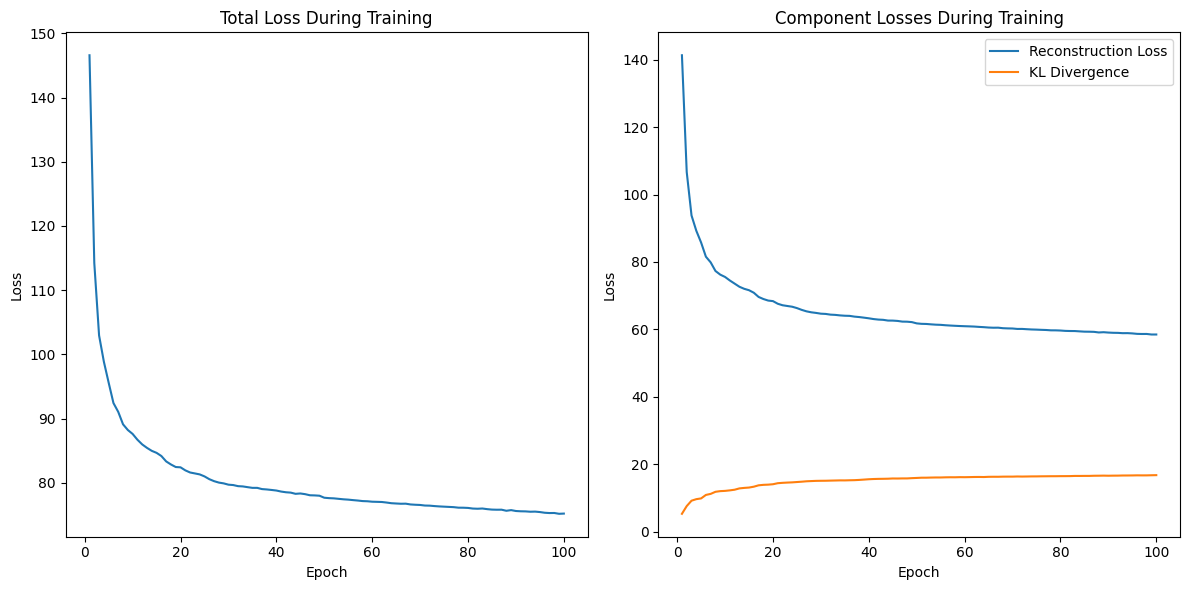

Loss plot saved to ../result/vae/vae_loss_plot.png


In [ ]:
# Plot the training losses
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Total Loss During Training')
plt.plot(range(1, num_epochs + 1), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.title('Component Losses During Training')
plt.plot(range(1, num_epochs + 1), recon_losses, label='Reconstruction Loss')
plt.plot(range(1, num_epochs + 1), kl_losses, label='KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

loss_plot_path = f'{RESULT_SAVE_PATH}/vae_loss_plot.png'
plt.tight_layout()
plt.savefig(loss_plot_path)
plt.show()
print(f"Loss plot saved to {loss_plot_path}")

## VAE结果分析与模型评估

VAE的性能可以从多个角度评估：

### 1. 重建质量

评估VAE重建输入图像的能力，通常通过以下方式进行评估：
- 视觉比较原始图像和重建图像
- 计算重建损失（如均方误差或交叉熵）

### 2. 生成质量

评估从潜在空间随机采样生成新图像的质量：
- 生成图像的清晰度和真实感
- 生成图像的多样性
- 使用定量指标如FID（Fréchet Inception Distance）

### 3. 潜在空间特性

评估潜在空间的结构和有意义性：
- 潜在空间插值的平滑过渡
- 潜在维度的解耦合程度
- 潜在空间聚类与语义对齐

### 4. 训练曲线分析

通过分析训练过程中损失函数的变化来评估模型的收敛情况：
- 总损失下降趋势
- 重建损失与KL散度的平衡
- 是否存在过拟合现象

在本实现中，我们通过跟踪损失变化、定期生成样本图像，以及比较不同训练阶段的模型性能来评估VAE。

Loading best model from epoch 99


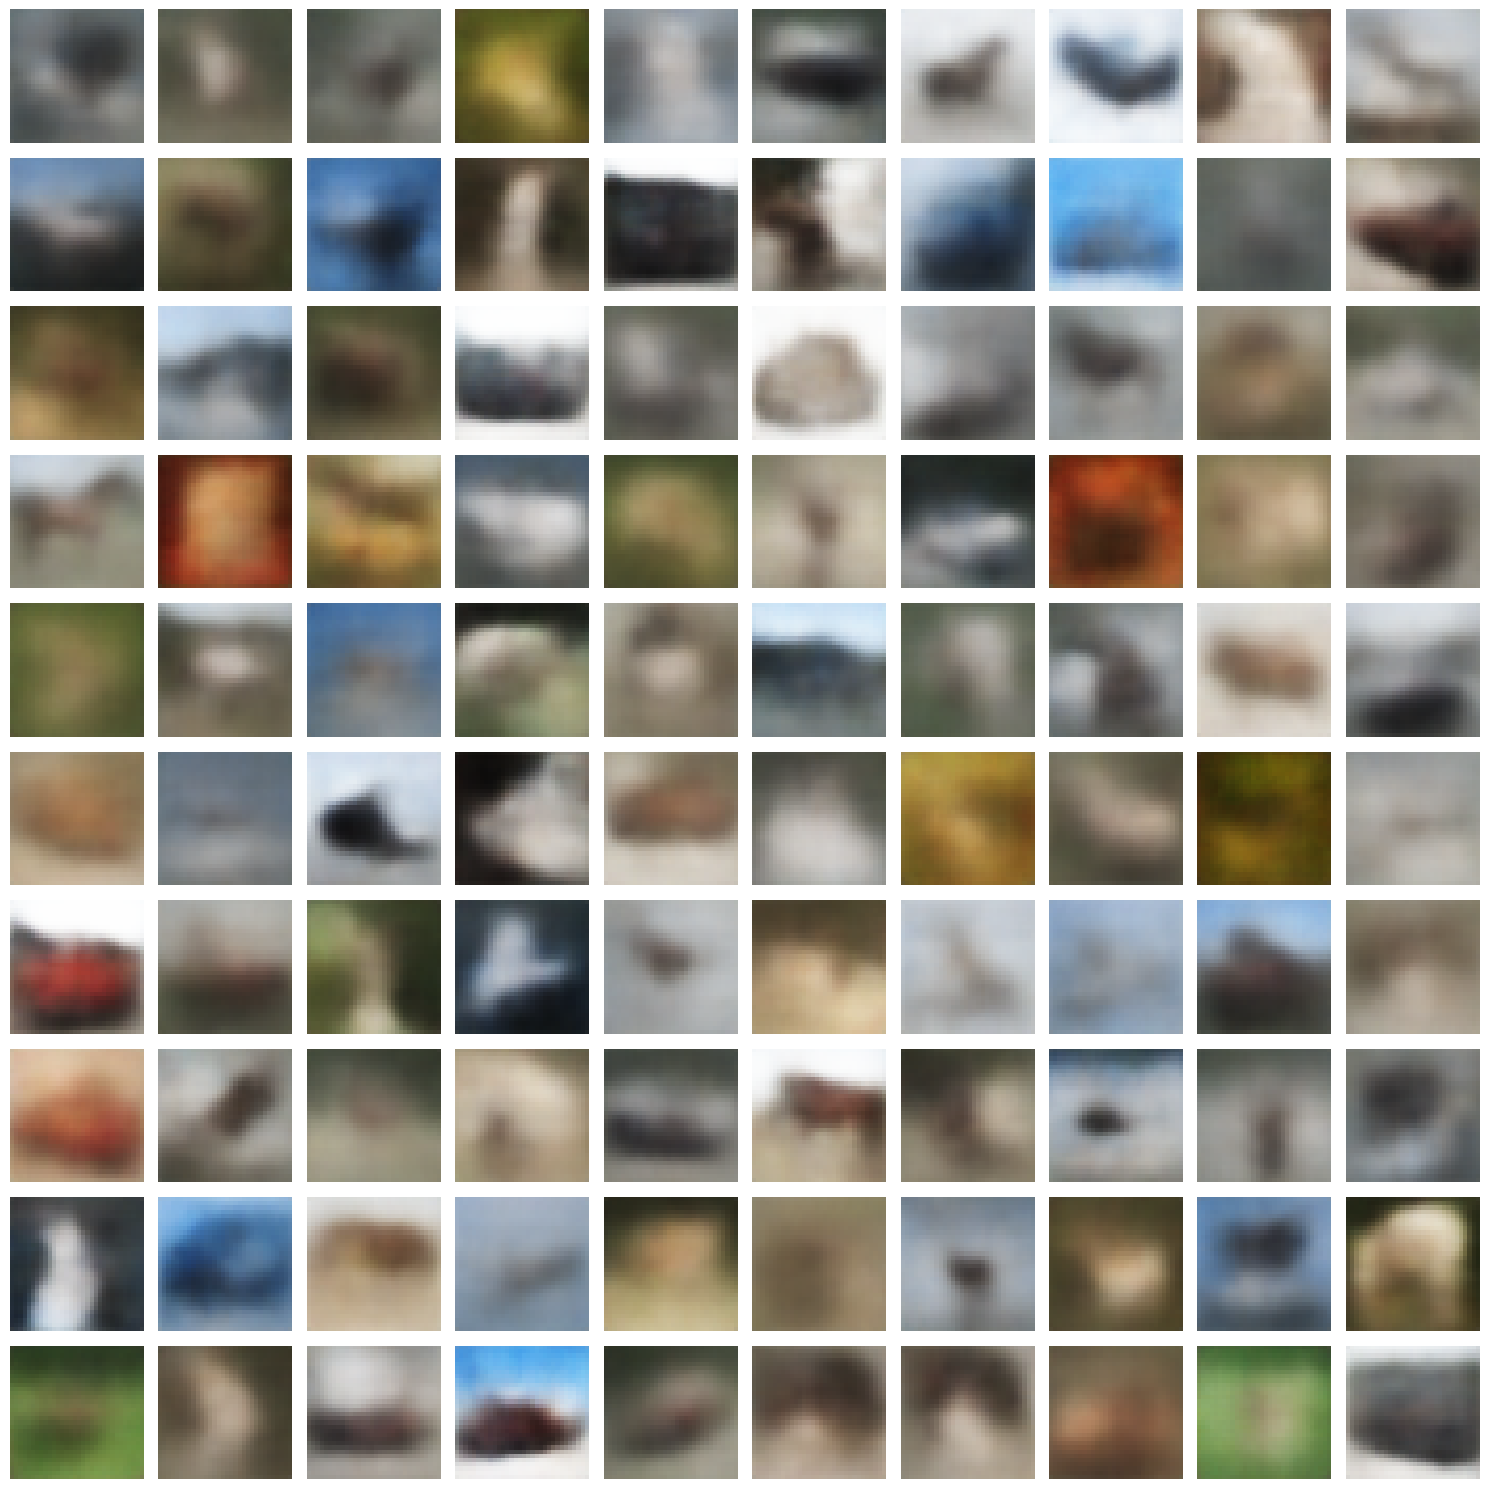

Best model samples saved to ../result/vae/vae_best_samples.png


In [11]:
print(f"Loading best model from epoch {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval()

with torch.no_grad():
    # Generate a larger set of samples
    n_samples = 100
    samples_per_row = 10
    sample = torch.randn(n_samples, latent_dim).to(device)
    generated = model.decode(sample).cpu()
    
    # Display samples in a grid
    fig, axes = plt.subplots(n_samples // samples_per_row, samples_per_row, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        ax.imshow(generated[i].permute(1, 2, 0).numpy())
        ax.axis('off')

    best_samples_path = f'{RESULT_SAVE_PATH}/vae_best_samples.png'
    plt.tight_layout()
    plt.savefig(best_samples_path)
    plt.show()
    print(f"Best model samples saved to {best_samples_path}")

# VAE模型总结与进阶方向

本实现实现了基于深度卷积网络的VAE应用于CIFAR-10彩色图像数据集。通过编码器-解码器架构和变分推断，模型能够从标准正态分布中采样并生成新的图像样本。

## 关键技术点

- **深度卷积架构**：使用多层卷积和转置卷积实现编码和解码
- **重参数化技巧**：实现可微分的随机采样过程
- **损失函数设计**：结合重建损失和KL散度实现ELBO最大化
- **残差连接**：促进梯度流动，提高深层网络的训练效果
- **定期可视化**：监控生成质量的变化和训练进展

## 可能的改进方向

1. **模型架构改进**：
   - 实现β-VAE增强解耦表示能力
   - 添加注意力机制捕捉更复杂的空间依赖关系
   - 使用更深的编码器/解码器或引入更先进的网络架构（如Transformer）

2. **损失函数改进**：
   - 尝试感知损失代替MSE以提升视觉质量
   - 实现循环一致性约束增强重建保真度
   - 调整KL散度项的权重以平衡重建与正则化

3. **混合模型**：
   - 结合VAE和GAN的优点（如VAE-GAN）
   - 实现条件VAE（CVAE）以控制生成过程
   - 探索层次化VAE捕捉不同层次的特征

4. **评估方法**：
   - 计算FID和IS等指标定量评估生成质量
   - 可视化潜在空间插值以验证连续性
   - 进行潜在空间解耦分析评估表示质量

VAE是一个具有扎实理论基础的生成模型，继续深入研究可以拓展到更多应用场景，如图像编辑、异常检测、半监督学习等。